In [24]:
"""
Fetch last 1 year of daily OHLCV candlestick data for multiple symbols (e.g. BTCUSDT, ETHUSDT).
Tries multiple Binance mirror endpoints to handle geo-restrictions (HTTP 451).
Falls back to CoinGecko if all Binance mirrors fail.
No API key required.
"""

import requests
import pandas as pd
from datetime import datetime, timedelta, timezone


# ── API endpoints to try in order ─────────────────────────────────────────────
ENDPOINTS = [
    "https://api1.binance.com/api/v3/klines",
    "https://api2.binance.com/api/v3/klines",
    "https://api3.binance.com/api/v3/klines",
    "https://api4.binance.com/api/v3/klines",
    "https://data-api.binance.vision/api/v3/klines",
]


def fetch_klines_from_url(url, symbol, interval, start_ms, end_ms):
    """Fetch klines from a specific URL with pagination."""
    all_klines = []
    current_start = start_ms

    while current_start < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": 1000,
        }
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if not data:
            break

        all_klines.extend(data)
        last_open_time = data[-1][0]
        current_start = last_open_time + 1

        if len(data) < 1000:
            break

    return all_klines


def fetch_binance_klines(symbol, interval, start_ms, end_ms):
    """Try each Binance mirror endpoint in order until one works."""
    for url in ENDPOINTS:
        try:
            print(f"  Trying: {url}")
            data = fetch_klines_from_url(url, symbol, interval, start_ms, end_ms)
            print(f"  Success!")
            return data
        except requests.HTTPError as e:
            print(f"  Failed ({e.response.status_code}), trying next...")
        except requests.ConnectionError:
            print(f"  Connection error, trying next...")

    raise RuntimeError(
        "All Binance endpoints failed (likely geo-restricted).\n"
        "Switching to CoinGecko fallback..."
    )


def fetch_coingecko_fallback(coin_id="bitcoin", days=365):
    """
    Fallback: fetch daily OHLCV from CoinGecko (free, no API key needed).
    coin_id examples: 'bitcoin', 'ethereum'
    - OHLC  : /coins/{coin_id}/ohlc          (4-hourly for 365d, resampled to daily)
    - Volume: /coins/{coin_id}/market_chart  (daily volume in USD)
    Both are merged into a single DataFrame.
    """
    print(f"\n  Trying CoinGecko fallback for '{coin_id}' (free, no API key)...")

    # ── 1. Fetch OHLC ──────────────────────────────────────────────────────
    ohlc_url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/ohlc"
    ohlc_resp = requests.get(ohlc_url, params={"vs_currency": "usd", "days": days}, timeout=15)
    ohlc_resp.raise_for_status()

    df_ohlc = pd.DataFrame(ohlc_resp.json(), columns=["timestamp", "open", "high", "low", "close"])
    df_ohlc["open_time"] = pd.to_datetime(df_ohlc["timestamp"], unit="ms", utc=True)
    df_ohlc.set_index("open_time", inplace=True)
    df_ohlc.drop(columns=["timestamp"], inplace=True)
    df_ohlc = df_ohlc.astype(float)

    # Resample 4-hourly → daily
    df_ohlc = df_ohlc.resample("1D").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last"}
    ).dropna()

    # ── 2. Fetch Volume (USD) via market_chart ─────────────────────────────
    chart_url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    chart_resp = requests.get(
        chart_url,
        params={"vs_currency": "usd", "days": days, "interval": "daily"},
        timeout=15
    )
    chart_resp.raise_for_status()
    chart_data = chart_resp.json()

    df_vol = pd.DataFrame(chart_data["total_volumes"], columns=["timestamp", "volume_usd"])
    df_vol["open_time"] = pd.to_datetime(df_vol["timestamp"], unit="ms", utc=True)
    df_vol.set_index("open_time", inplace=True)
    df_vol.drop(columns=["timestamp"], inplace=True)
    df_vol["volume_usd"] = df_vol["volume_usd"].astype(float)
    df_vol = df_vol.resample("1D").sum()

    # ── 3. Merge OHLC + Volume ─────────────────────────────────────────────
    df = df_ohlc.join(df_vol, how="left")
    df["volume_coin"] = df["volume_usd"] / df["close"]

    print(f"  CoinGecko OHLCV data fetched successfully for '{coin_id}'!")
    return df


def klines_to_dataframe(klines):
    """Convert raw Binance kline list to a clean Pandas DataFrame."""
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "num_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]
    df = pd.DataFrame(klines, columns=columns)

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)

    float_cols = ["open", "high", "low", "close", "volume",
                  "quote_asset_volume", "taker_buy_base_volume", "taker_buy_quote_volume"]
    df[float_cols] = df[float_cols].astype(float)
    df["num_trades"] = df["num_trades"].astype(int)

    # Rename for clarity: volume = coin volume, quote_asset_volume = USDT volume
    df.rename(columns={"volume": "volume_coin", "quote_asset_volume": "volume_usd"}, inplace=True)

    df = df[["open_time", "open", "high", "low", "close",
             "volume_coin", "volume_usd", "num_trades", "close_time"]]
    df.set_index("open_time", inplace=True)
    return df


def print_summary(df, symbol=""):
    label = f" [{symbol}]" if symbol else ""
    print(f"\n--- First 5 rows{label} ---")
    print(df.head())
    print(f"\n--- Last 5 rows{label} ---")
    print(df.tail())
    print(f"\nShape: {df.shape}")
    print(f"\n--- Price Summary{label} ---")
    print(f"  Highest Close  : ${df['close'].max():,.2f}")
    print(f"  Lowest  Close  : ${df['close'].min():,.2f}")
    print(f"  Latest  Close  : ${df['close'].iloc[-1]:,.2f}")
    vol_col = "volume_coin" if "volume_coin" in df.columns else "volume_btc"
    if vol_col in df.columns:
        print(f"  Avg Daily Vol  : {df[vol_col].mean():,.2f} {symbol.replace('USDT','')}")
    if "volume_usd" in df.columns:
        print(f"  Avg Daily Vol  : ${df['volume_usd'].mean():,.0f} USD")


def fetch_symbol(symbol, interval, start_ms, end_ms):
    """Fetch OHLCV data for a single symbol, with CoinGecko fallback."""
    # Maps Binance symbol → CoinGecko coin_id
    coingecko_ids = {
        "BTCUSDT": "bitcoin",
        "ETHUSDT": "ethereum",
    }

    try:
        klines = fetch_binance_klines(symbol, interval, start_ms, end_ms)
        print(f"  Total candles fetched: {len(klines)}")
        return klines_to_dataframe(klines), "binance"
    except RuntimeError as e:
        print(f"\n{e}")
        coin_id = coingecko_ids.get(symbol, symbol.replace("USDT", "").lower())
        df = fetch_coingecko_fallback(coin_id=coin_id, days=365)
        return df, "coingecko"


def main():
    symbols  = ["BTCUSDT", "ETHUSDT"]   # ← Add more symbols here if needed
    interval = "1d"

    now          = datetime.now(timezone.utc)
    one_year_ago = now - timedelta(days=365)
    start_ms     = int(one_year_ago.timestamp() * 1000)
    end_ms       = int(now.timestamp() * 1000)

    results = {}

    for symbol in symbols:
        print(f"\n{'='*55}")
        print(f"  Fetching {symbol} daily data: {one_year_ago.date()} → {now.date()}")
        print(f"{'='*55}")

        df, source = fetch_symbol(symbol, interval, start_ms, end_ms)
        print_summary(df, symbol)

        csv_filename = f"{symbol}_daily_1year{'_coingecko' if source == 'coingecko' else ''}.csv"
        df.to_csv(csv_filename)
        print(f"\n  Data saved to '{csv_filename}'")

        results[symbol] = df

    print(f"\n{'='*55}")
    print(f"  Done! Fetched data for: {', '.join(results.keys())}")
    print(f"{'='*55}\n")

    return results


if __name__ == "__main__":
    data = main()
    df_btc = data["BTCUSDT"]
    df_eth = data["ETHUSDT"]


  Fetching BTCUSDT daily data: 2025-03-06 → 2026-03-06
  Trying: https://api1.binance.com/api/v3/klines
  Success!
  Total candles fetched: 365

--- First 5 rows [BTCUSDT] ---
                               open      high       low     close  \
open_time                                                           
2025-03-07 00:00:00+00:00  89931.88  91283.02  84667.03  86801.75   
2025-03-08 00:00:00+00:00  86801.74  86897.25  85218.47  86222.45   
2025-03-09 00:00:00+00:00  86222.46  86500.00  80000.00  80734.37   
2025-03-10 00:00:00+00:00  80734.48  84123.46  77459.91  78595.86   
2025-03-11 00:00:00+00:00  78595.86  83617.40  76606.00  82932.99   

                           volume_coin    volume_usd  num_trades  \
open_time                                                          
2025-03-07 00:00:00+00:00  57980.35713  5.097555e+09     9510442   
2025-03-08 00:00:00+00:00  12989.23054  1.119359e+09     2553974   
2025-03-09 00:00:00+00:00  26115.39345  2.173553e+09     5189138   

In [25]:
df = pd.read_csv("BTCUSDT_daily_1year.csv")
df

,open_time,open,high,low,close,volume_coin,volume_usd,num_trades,close_time
0,2025-03-07 00:00:00+00:00,89931.88,91283.02,84667.03,86801.75,57980.35713,5.097555e+09,9510442,2025-03-07 23:59:59.999000+00:00
1,2025-03-08 00:00:00+00:00,86801.74,86897.25,85218.47,86222.45,12989.23054,1.119359e+09,2553974,2025-03-08 23:59:59.999000+00:00
2,2025-03-09 00:00:00+00:00,86222.46,86500.00,80000.00,80734.37,26115.39345,2.173553e+09,5189138,2025-03-09 23:59:59.999000+00:00
3,2025-03-10 00:00:00+00:00,80734.48,84123.46,77459.91,78595.86,47633.38405,3.834925e+09,8701538,2025-03-10 23:59:59.999000+00:00
4,2025-03-11 00:00:00+00:00,78595.86,83617.40,76606.00,82932.99,48770.06853,3.927001e+09,6983310,2025-03-11 23:59:59.999000+00:00
...,...,...,...,...,...,...,...,...,...
360,2026-03-02 00:00:00+00:00,65776.48,70096.00,65259.21,68830.06,32010.38431,2.164579e+09,8397526,2026-03-02 23:59:59.999000+00:00
361,2026-03-03 00:00:00+00:00,68830.06,69258.08,66158.00,68338.00,24972.24180,1.691849e+09,7648119,2026-03-03 23:59:59.999000+00:00
362,2026-03-04 00:00:00+00:00,68338.01,74050.00,67400.00,72666.77,44919.07610,3.202864e+09,8618302,2026-03-04 23:59:59.999000+00:00
363,2026-03-05 00:00:00+00:00,72666.77,73558.15,70645.47,70890.72,26590.51253,1.917515e+09,6709160,2026-03-05 23:59:59.999000+00:00


In [26]:
pip install mplfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
df.head()

,open_time,open,high,low,close,volume_coin,volume_usd,num_trades,close_time
0,2025-03-07 00:00:00+00:00,89931.88,91283.02,84667.03,86801.75,57980.35713,5.097555e+09,9510442,2025-03-07 23:59:59.999000+00:00
1,2025-03-08 00:00:00+00:00,86801.74,86897.25,85218.47,86222.45,12989.23054,1.119359e+09,2553974,2025-03-08 23:59:59.999000+00:00
2,2025-03-09 00:00:00+00:00,86222.46,86500.00,80000.00,80734.37,26115.39345,2.173553e+09,5189138,2025-03-09 23:59:59.999000+00:00
3,2025-03-10 00:00:00+00:00,80734.48,84123.46,77459.91,78595.86,47633.38405,3.834925e+09,8701538,2025-03-10 23:59:59.999000+00:00
4,2025-03-11 00:00:00+00:00,78595.86,83617.40,76606.00,82932.99,48770.06853,3.927001e+09,6983310,2025-03-11 23:59:59.999000+00:00


In [28]:
df.dtypes

open_time          str
open           float64
high           float64
low            float64
close          float64
volume_coin    float64
volume_usd     float64
num_trades       int64
close_time         str
dtype: object

In [29]:
df.isnull().sum()

open_time      0
open           0
high           0
low            0
close          0
volume_coin    0
volume_usd     0
num_trades     0
close_time     0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.shape

(365, 9)

In [32]:
numeric_columns = ["open", "high", "low", "close", "volume_coin", "volume_usd", "num_trades"]

In [33]:
# Converting these columns into float
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, axis=1)

In [34]:
df.dtypes

open_time          str
open           float64
high           float64
low            float64
close          float64
volume_coin    float64
volume_usd     float64
num_trades     float64
close_time         str
dtype: object

In [35]:
df.describe()

,open,high,low,close,volume_coin,volume_usd,num_trades
count,365.000000,365.000000,365.000000,365.000000,365.000000,3.650000e+02,3.650000e+02
mean,98534.938740,100036.355945,96836.160740,98482.822082,19867.228142,1.900687e+09,3.833877e+06
std,15135.848051,15067.297884,15284.076712,15198.166702,12555.607071,1.069145e+09,2.248972e+06
min,62909.870000,65026.750000,60000.000000,62909.860000,3104.117220,2.228733e+08,6.533050e+05
25%,87369.970000,88860.000000,85860.000000,87369.560000,11793.866150,1.174001e+09,2.214249e+06
50%,102312.950000,104192.700000,100300.950000,102312.940000,17517.418230,1.708989e+09,3.268475e+06
75%,111004.900000,112575.270000,109394.810000,111004.890000,23936.328000,2.361590e+09,5.010211e+06
max,124658.540000,126199.630000,123084.000000,124658.540000,106298.828990,7.349751e+09,1.536401e+07


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open_time    365 non-null    str    
 1   open         365 non-null    float64
 2   high         365 non-null    float64
 3   low          365 non-null    float64
 4   close        365 non-null    float64
 5   volume_coin  365 non-null    float64
 6   volume_usd   365 non-null    float64
 7   num_trades   365 non-null    float64
 8   close_time   365 non-null    str    
dtypes: float64(7), str(2)
memory usage: 25.8 KB


In [37]:
df['open_time'] = pd.to_datetime(df['open_time'])
df['open_time'] = df['open_time'].dt.strftime('%Y-%m-%d')

df['close_time'] = pd.to_datetime(df['close_time'])
df['close_time'] = df['close_time'].dt.strftime('%Y-%m-%d')

In [38]:
df

,open_time,open,high,low,close,volume_coin,volume_usd,num_trades,close_time
0,2025-03-07,89931.88,91283.02,84667.03,86801.75,57980.35713,5.097555e+09,9510442.0,2025-03-07
1,2025-03-08,86801.74,86897.25,85218.47,86222.45,12989.23054,1.119359e+09,2553974.0,2025-03-08
2,2025-03-09,86222.46,86500.00,80000.00,80734.37,26115.39345,2.173553e+09,5189138.0,2025-03-09
3,2025-03-10,80734.48,84123.46,77459.91,78595.86,47633.38405,3.834925e+09,8701538.0,2025-03-10
4,2025-03-11,78595.86,83617.40,76606.00,82932.99,48770.06853,3.927001e+09,6983310.0,2025-03-11
...,...,...,...,...,...,...,...,...,...
360,2026-03-02,65776.48,70096.00,65259.21,68830.06,32010.38431,2.164579e+09,8397526.0,2026-03-02
361,2026-03-03,68830.06,69258.08,66158.00,68338.00,24972.24180,1.691849e+09,7648119.0,2026-03-03
362,2026-03-04,68338.01,74050.00,67400.00,72666.77,44919.07610,3.202864e+09,8618302.0,2026-03-04
363,2026-03-05,72666.77,73558.15,70645.47,70890.72,26590.51253,1.917515e+09,6709160.0,2026-03-05


In [39]:
df.rename(columns={'volume_coin': 'volume'}, inplace=True)

In [40]:
df

,open_time,open,high,low,close,volume,volume_usd,num_trades,close_time
0,2025-03-07,89931.88,91283.02,84667.03,86801.75,57980.35713,5.097555e+09,9510442.0,2025-03-07
1,2025-03-08,86801.74,86897.25,85218.47,86222.45,12989.23054,1.119359e+09,2553974.0,2025-03-08
2,2025-03-09,86222.46,86500.00,80000.00,80734.37,26115.39345,2.173553e+09,5189138.0,2025-03-09
3,2025-03-10,80734.48,84123.46,77459.91,78595.86,47633.38405,3.834925e+09,8701538.0,2025-03-10
4,2025-03-11,78595.86,83617.40,76606.00,82932.99,48770.06853,3.927001e+09,6983310.0,2025-03-11
...,...,...,...,...,...,...,...,...,...
360,2026-03-02,65776.48,70096.00,65259.21,68830.06,32010.38431,2.164579e+09,8397526.0,2026-03-02
361,2026-03-03,68830.06,69258.08,66158.00,68338.00,24972.24180,1.691849e+09,7648119.0,2026-03-03
362,2026-03-04,68338.01,74050.00,67400.00,72666.77,44919.07610,3.202864e+09,8618302.0,2026-03-04
363,2026-03-05,72666.77,73558.15,70645.47,70890.72,26590.51253,1.917515e+09,6709160.0,2026-03-05


In [ ]:
# Adding Percentage Change from last close price
df['percentage_change'] = (df['close'].pct_change() * 100).round(2)
df

,open_time,open,high,low,close,volume,volume_usd,num_trades,close_time,percentage_change
0,2025-03-07,89931.88,91283.02,84667.03,86801.75,57980.35713,5.097555e+09,9510442.0,2025-03-07,NaN
1,2025-03-08,86801.74,86897.25,85218.47,86222.45,12989.23054,1.119359e+09,2553974.0,2025-03-08,-0.67
2,2025-03-09,86222.46,86500.00,80000.00,80734.37,26115.39345,2.173553e+09,5189138.0,2025-03-09,-6.37
3,2025-03-10,80734.48,84123.46,77459.91,78595.86,47633.38405,3.834925e+09,8701538.0,2025-03-10,-2.65
4,2025-03-11,78595.86,83617.40,76606.00,82932.99,48770.06853,3.927001e+09,6983310.0,2025-03-11,5.52
...,...,...,...,...,...,...,...,...,...,...
360,2026-03-02,65776.48,70096.00,65259.21,68830.06,32010.38431,2.164579e+09,8397526.0,2026-03-02,4.64
361,2026-03-03,68830.06,69258.08,66158.00,68338.00,24972.24180,1.691849e+09,7648119.0,2026-03-03,-0.71
362,2026-03-04,68338.01,74050.00,67400.00,72666.77,44919.07610,3.202864e+09,8618302.0,2026-03-04,6.33
363,2026-03-05,72666.77,73558.15,70645.47,70890.72,26590.51253,1.917515e+09,6709160.0,2026-03-05,-2.44


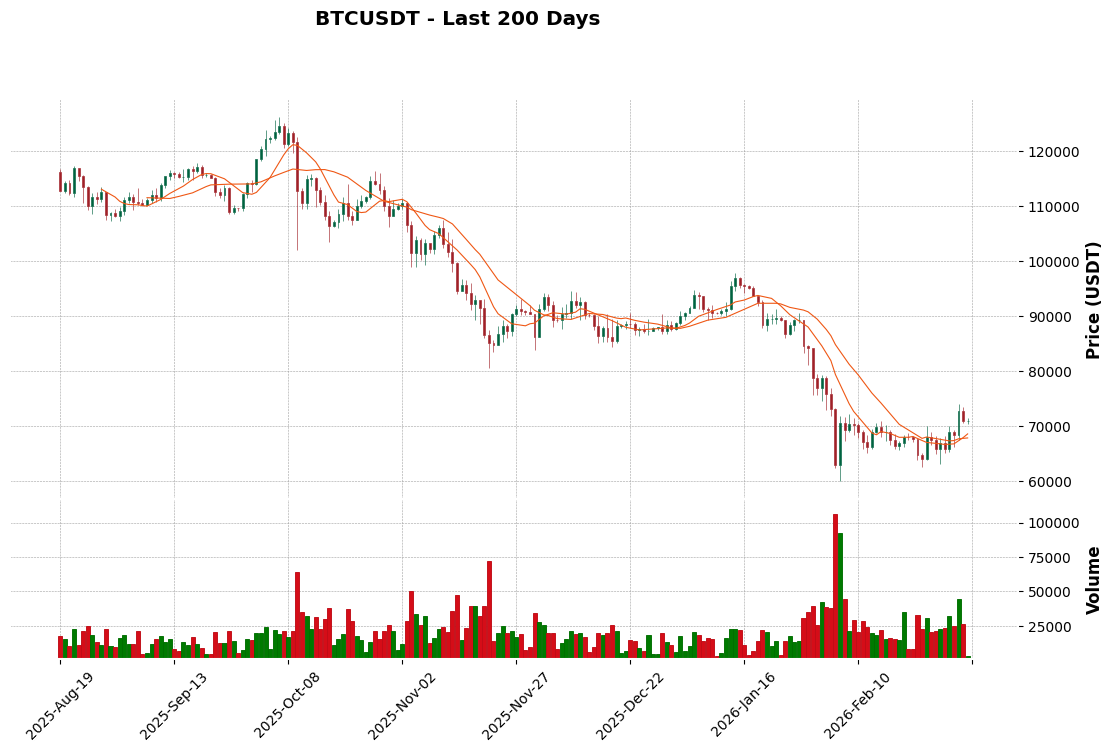

In [41]:
import mplfinance as mpf
import pandas as pd

# Step 1: Convert open_time to datetime and set as index
df['open_time'] = pd.to_datetime(df['open_time'])
df_plot = df.set_index('open_time')

# Step 2: Plot candlestick chart
mpf.plot(
    df_plot.tail(200),
    type='candle',          # candlestick chart
    style='charles',        # clean style (try 'yahoo', 'binance', 'nightclouds')
    volume=True,            # volume bars at bottom
    title='BTCUSDT - Last 200 Days',
    ylabel='Price (USDT)',
    ylabel_lower='Volume',
    figsize=(14, 8),
    mav=(10,20)
)